In [1]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'src'))

from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from datetime import date
plt.rcParams["figure.figsize"] = (24,18)

from cv_utils import *
from keypoint_detection import *

import albumentations

### Load data

In [7]:
merge = False
convert = False
data_path = os.path.join(os.path.dirname(os.getcwd()), 'data')
folder_name_1 = 'real_keypoint_train'
folder_name_2 = 'synth_keypoint_train'
if convert:
    cvat2coco(folder_name_1, data_path)
    cvat2coco(folder_name_2 , data_path)

coco_dataset_path_1 = os.path.join(data_path, 'coco_datasets/real_keypoint_train')
coco_dataset_path_2 = os.path.join(data_path, 'coco_datasets/synth_keypoint_train')
if merge:
    dest_path=os.path.join(data_path, 'coco_datasets')
    merge_dest_path = merge_coco_dataset(coco_dataset_path_1, coco_dataset_path_2,
                    dest_path=os.path.join(data_path, 'coco_datasets'))
    merge_dest_path = os.path.dirname(merge_dest_path)
else:
    merge_dest_path = os.path.join(data_path, 'coco_datasets/real_synth_keypoint_train')

[[ 776  539]
 [ 766  336]
 [2335  378]
 [ 787  799]]


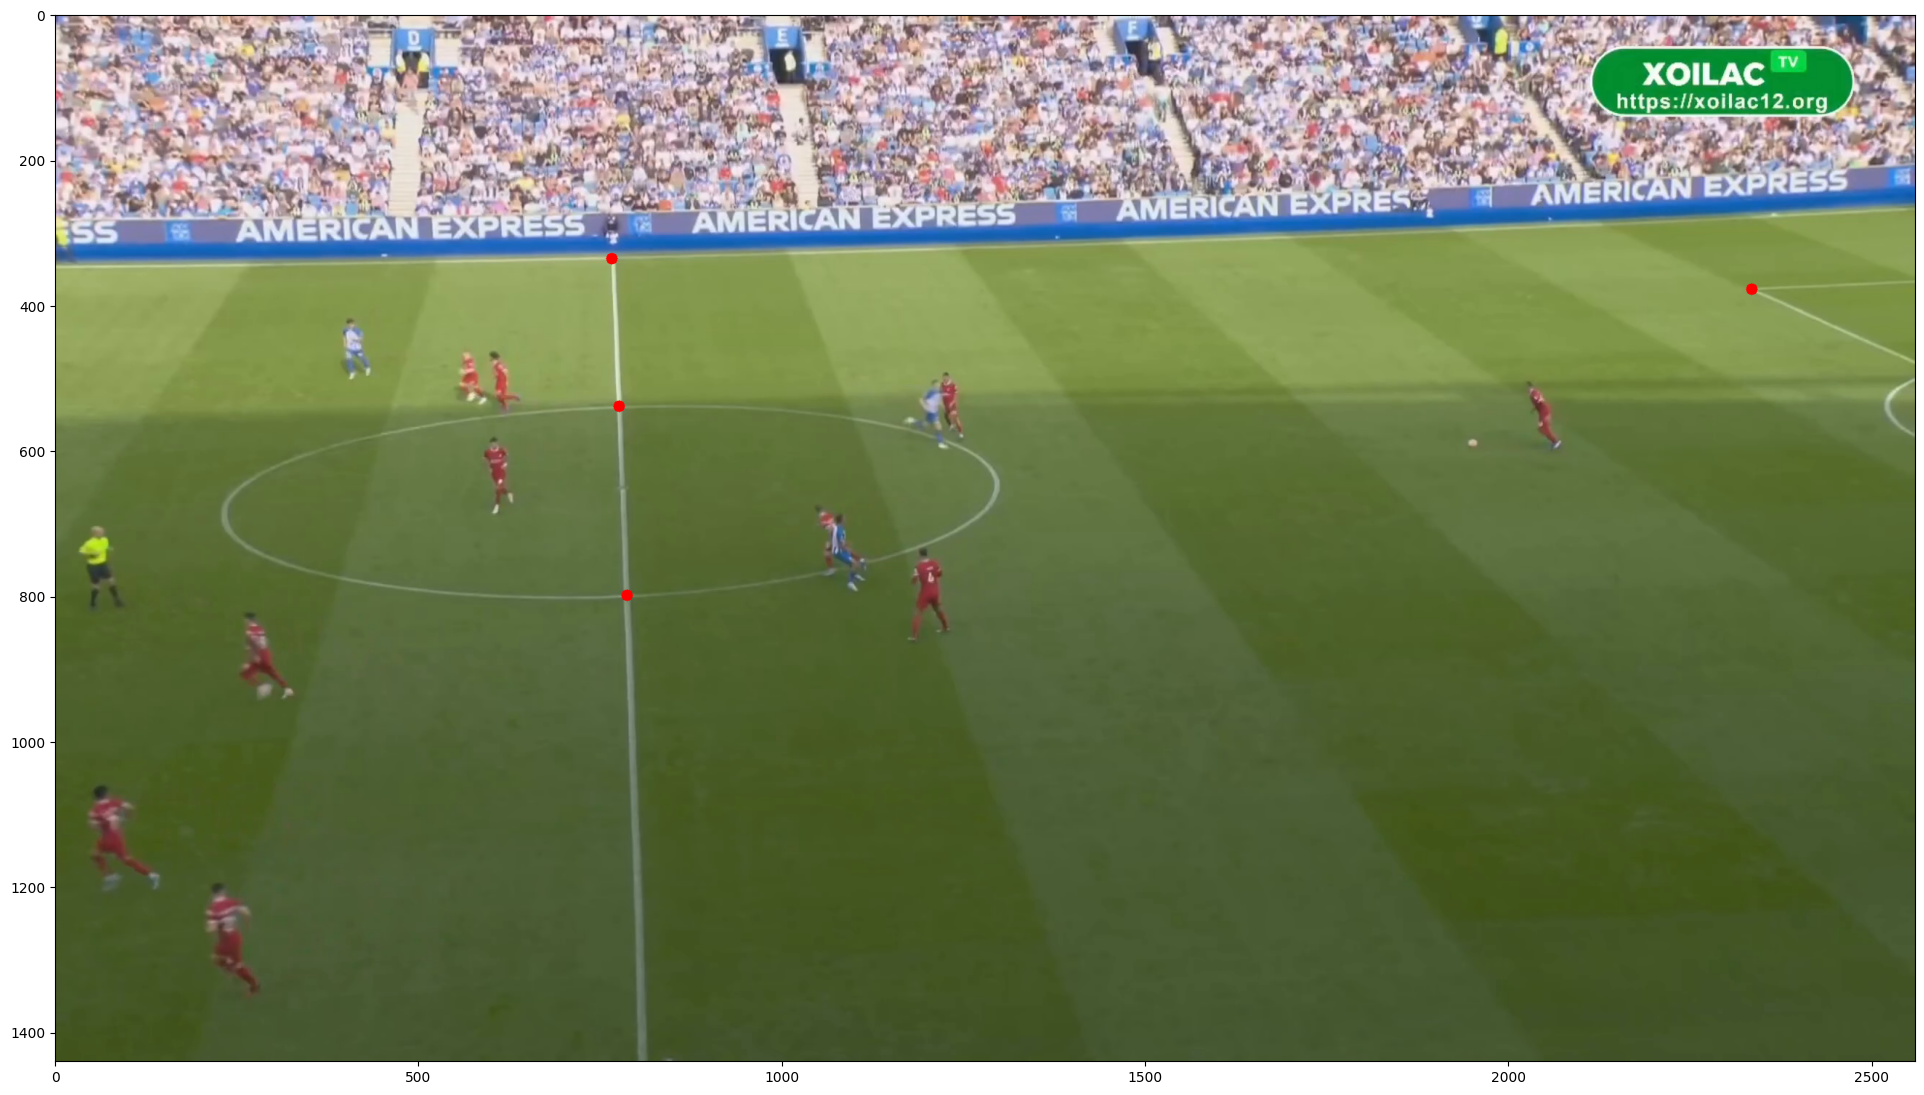

In [8]:
image_folder = os.path.join(merge_dest_path, "images")
annotation_file = os.path.join(merge_dest_path, "annotations", "instances_default.json")

with open(annotation_file, 'r') as f:
    annotations = json.load(f)

image_id = 1
image_name = [image_info["file_name"] for image_info in annotations['images']
                                        if image_info['id'] == image_id][0]
keypoint_list = np.array([np.array(annotation["keypoint"])
                    for annotation in annotations['annotations']
                    if annotation['image_id'] == image_id], dtype=np.int32)

image_path = os.path.join(image_folder, image_name)
image = cv2.cvtColor(cv2.imread(image_path, 
                                        cv2.IMREAD_UNCHANGED), cv2.COLOR_BGR2RGB)

print(keypoint_list)
temp = image.copy()
for keypoint in keypoint_list:
    temp = cv2.circle(image, keypoint, radius=8, color=(255, 0, 0), thickness=-1)
plt.figure()
plt.imshow(temp)

In [ ]:
image_folder = os.path.join(merge_dest_path, "images")
annotation_file = os.path.join(merge_dest_path, "annotations", "instances_default.json")

transform = albumentations.Compose([
        albumentations.Resize(576, 1024),
        albumentations.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.5),
        albumentations.HorizontalFlip(p=0.5),
        albumentations.VerticalFlip(p=0.5)
        ])

dataset = KeypointDataset(image_folder=image_folder, annotation_file=annotation_file
                       , transform=transform)
data_loader = DataLoader(dataset, batch_size=16, shuffle=True)
images, masks = next(iter(data_loader))

for i in range(8):
    plt.figure()
    plt.subplot(1, 3, 1)
    plt.imshow(images[i].permute(1, 2, 0).numpy())
    plt.title("Image")
    plt.subplot(1, 3, 2)
    plt.imshow(masks[i].permute(1, 2, 0).numpy().astype(np.int32)*255)
    plt.title("Mask")

### Train model

### Inference